# Cross-Dataset Network Intrusion Detection System (CD-NIDS)
## Train on CICIDS2017 → Validate on CICIDS2017 → Test on CSE-CIC-IDS2018

This comprehensive pipeline implements a two-stage IDS detection system that:
- **Stage 1**: Binary classification (Benign vs Attack)
- **Stage 2**: Multi-class attack classification


# =============================================================================
# 1. IMPORTS AND SETUP
# =============================================================================
* Imports libraries for data handling, visualization, and machine learning.
* Sets up preprocessing tools, feature selection, and dimensionality‑reduction utilities.
* Loads multiple classification models (sklearn, LightGBM, XGBoost).
* Configures random seed, plotting style, and prints a success message.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import time
import glob
import os
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, 
                             precision_score, recall_score, f1_score, roc_auc_score,
                             roc_curve)
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
import lightgbm as lgb
import xgboost as xgb
import warnings
import json
import zipfile
import joblib
from datetime import datetime
!pip install skl2onnx
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
warnings.filterwarnings("ignore")  
os.environ["PYTHONWARNINGS"] = "ignore"
XGB_AVAILABLE=True
LGB_AVAILABLE=True
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
print("LIBRARIES LOADED SUCCESSFULLY")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 11.4 MB/s eta 0:00:00
LIBRARIES LOADED SUCCESSFULLY


# =============================================================================
# 2. DATA LOADING - CICIDS2017 (TRAINING + VALIDATION)
# =============================================================================
* Defines the dataset path and the list of CICIDS2017 CSV files to load.
* Iterates through each file, reads it into a DataFrame, logs success/errors, and stores it in a list.
* Concatenates all loaded CSVs into a single dataset and cleans column names.
* Prints dataset shape, column names, and unique attack types from the "Label" column.

In [3]:
path_2017 = "/kaggle/input/datasets/chethuhn/network-intrusion-dataset/"
files_2017 = [
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv"
]
print("Loading CICIDS2017 dataset...")
dfs_2017 = []

for file in files_2017:
    file_path = path_2017 + file
    try:
        df = pd.read_csv(file_path)
        dfs_2017.append(df)
        print(f"Loaded: {file} ({len(df):,} rows)")
    except Exception as e:
        print(f"Error loading {file}: {e}")

data_2017 = pd.concat(dfs_2017, ignore_index=True)
data_2017.columns = data_2017.columns.str.strip()
print(f"CICIDS2017 Dataset Shape: {data_2017.shape}")
print(f"\nColumn names ({len(data_2017.columns)}):")
print(data_2017.columns.tolist())
print("Distinct Attack Types:")
print(data_2017["Label"].unique())

Loading CICIDS2017 dataset...
Loaded: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv (225,745 rows)
Loaded: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv (286,467 rows)
Loaded: Friday-WorkingHours-Morning.pcap_ISCX.csv (191,033 rows)
Loaded: Monday-WorkingHours.pcap_ISCX.csv (529,918 rows)
Loaded: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv (288,602 rows)
Loaded: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv (170,366 rows)
Loaded: Tuesday-WorkingHours.pcap_ISCX.csv (445,909 rows)
Loaded: Wednesday-workingHours.pcap_ISCX.csv (692,703 rows)
CICIDS2017 Dataset Shape: (2830743, 79)

Column names (79):
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/

# =============================================================================
# 3. DATA LOADING - CSE-CIC-IDS2018 (TESTING)
# =============================================================================
* Defines the file path and list of CIC‑IDS2018 FlowMeter CSV files.
* Loads each file (up to 300,000 rows per file) into DataFrames while logging success/errors.
* Merges all DataFrames into one dataset and trims column names.
* Prints overall dataset shape, column names, and unique attack labels.

In [4]:
path_2018 = "/kaggle/input/datasets/masjohncook/cse-cic-ids2018-cicflowmeter/"
files_2018 = [
    "Friday-16-02-2018_TrafficForML_CICFlowMeter.csv",
    "Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv",
    "Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv",
    "Friday-02-03-2018_TrafficForML_CICFlowMeter.csv",
    "Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv",
    "Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv",
    "Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv",
    "Friday-23-02-2018_TrafficForML_CICFlowMeter.csv",
    "Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv",
    "Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv"
]
print("Loading CSE-CIC-IDS2018 dataset")
dfs_2018 = []
for file in files_2018:
    file_path = path_2018 + file
    try:
        df = pd.read_csv(file_path, nrows=300000)
        dfs_2018.append(df)
        print(f"  ✓ Loaded: {file} ({len(df):,} rows)")
    except Exception as e:
        print(f"  ✗ Error loading {file}: {e}")
data_2018 = pd.concat(dfs_2018, ignore_index=True)
data_2018.columns = data_2018.columns.str.strip()
print(f"CSE-CIC-IDS2018 Dataset Shape: {data_2018.shape}")
print(f"\nColumn names ({len(data_2018.columns)}):")
print(data_2018.columns.tolist())
print("Distinct Attack Types:")
print(data_2018["Label"].unique())

Loading CSE-CIC-IDS2018 dataset
  ✓ Loaded: Friday-16-02-2018_TrafficForML_CICFlowMeter.csv (300,000 rows)
  ✓ Loaded: Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv (300,000 rows)
  ✓ Loaded: Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv (300,000 rows)
  ✓ Loaded: Friday-02-03-2018_TrafficForML_CICFlowMeter.csv (300,000 rows)
  ✓ Loaded: Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv (300,000 rows)
  ✓ Loaded: Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv (300,000 rows)
  ✓ Loaded: Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv (300,000 rows)
  ✓ Loaded: Friday-23-02-2018_TrafficForML_CICFlowMeter.csv (300,000 rows)
  ✓ Loaded: Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv (300,000 rows)
  ✓ Loaded: Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv (300,000 rows)
CSE-CIC-IDS2018 Dataset Shape: (3000000, 84)

Column names (84):
['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Le

# =============================================================================
# 4. COLUMN ALIGNMENT BETWEEN 2017 AND 2018 DATASETS
# =============================================================================
* Defines a mapping of mismatched column names from the 2018 dataset to their equivalent names in the 2017 schema.
* Uses this mapping to rename 2018 columns so both datasets have consistent feature names.
* Ensures compatibility for future merging, feature alignment, and model training.
* Prints a confirmation once the renaming process is completed.

In [5]:
print("\nAligning 2018 columns to match 2017 schema.")
column_mapping = {

    'Dst Port': 'Destination Port',
    'Tot Fwd Pkts': 'Total Fwd Packets',
    'Tot Bwd Pkts': 'Total Backward Packets',

    'TotLen Fwd Pkts': 'Total Length of Fwd Packets',
    'TotLen Bwd Pkts': 'Total Length of Bwd Packets',

    'Fwd Pkt Len Max': 'Fwd Packet Length Max',
    'Fwd Pkt Len Min': 'Fwd Packet Length Min',
    'Fwd Pkt Len Mean': 'Fwd Packet Length Mean',
    'Fwd Pkt Len Std': 'Fwd Packet Length Std',

    'Bwd Pkt Len Max': 'Bwd Packet Length Max',
    'Bwd Pkt Len Min': 'Bwd Packet Length Min',
    'Bwd Pkt Len Mean': 'Bwd Packet Length Mean',
    'Bwd Pkt Len Std': 'Bwd Packet Length Std',

    'Flow Byts/s': 'Flow Bytes/s',
    'Flow Pkts/s': 'Flow Packets/s',

    'Fwd IAT Tot': 'Fwd IAT Total',
    'Bwd IAT Tot': 'Bwd IAT Total',

    'Fwd Header Len': 'Fwd Header Length',
    'Bwd Header Len': 'Bwd Header Length',

    'Fwd Pkts/s': 'Fwd Packets/s',
    'Bwd Pkts/s': 'Bwd Packets/s',

    'Pkt Len Min': 'Min Packet Length',
    'Pkt Len Max': 'Max Packet Length',
    'Pkt Len Mean': 'Packet Length Mean',
    'Pkt Len Std': 'Packet Length Std',
    'Pkt Len Var': 'Packet Length Variance',

    'FIN Flag Cnt': 'FIN Flag Count',
    'SYN Flag Cnt': 'SYN Flag Count',
    'RST Flag Cnt': 'RST Flag Count',
    'PSH Flag Cnt': 'PSH Flag Count',
    'ACK Flag Cnt': 'ACK Flag Count',
    'URG Flag Cnt': 'URG Flag Count',

    'ECE Flag Cnt': 'ECE Flag Count',

    'Pkt Size Avg': 'Average Packet Size',
    'Fwd Seg Size Avg': 'Avg Fwd Segment Size',
    'Bwd Seg Size Avg': 'Avg Bwd Segment Size',

    'Subflow Fwd Pkts': 'Subflow Fwd Packets',
    'Subflow Fwd Byts': 'Subflow Fwd Bytes',
    'Subflow Bwd Pkts': 'Subflow Bwd Packets',
    'Subflow Bwd Byts': 'Subflow Bwd Bytes',

    'Init Fwd Win Byts': 'Init_Win_bytes_forward',
    'Init Bwd Win Byts': 'Init_Win_bytes_backward',

    'Fwd Act Data Pkts': 'act_data_pkt_fwd',
    'Fwd Seg Size Min': 'min_seg_size_forward'
}

data_2018.rename(columns=column_mapping, inplace=True)
print("Column renaming complete.")


Aligning 2018 columns to match 2017 schema.
Column renaming complete.


# =============================================================================
# 5. KEEP ONLY COMMON COLUMNS
# =============================================================================
* Computes the set of columns in both 2017 and 2018 datasets and identifies their intersection (common columns).
* Filters both datasets to keep only the shared columns, ensuring identical schemas.
* Prints the number of columns in each dataset and how many are common.
* Shows the final aligned shapes of both datasets after column selection.

In [6]:
print("\nFinding common columns.")
cols_2017 = set(data_2017.columns)
cols_2018 = set(data_2018.columns)
common_columns = list(cols_2017.intersection(cols_2018))
print("Columns in 2017:", len(cols_2017))
print("Columns in 2018:", len(cols_2018))
print("Common columns:", len(common_columns))
data_2017 = data_2017[common_columns]
data_2018 = data_2018[common_columns]
print("Datasets aligned.")
print("2017 shape:", data_2017.shape)
print("2018 shape:", data_2018.shape)


Finding common columns.
Columns in 2017: 79
Columns in 2018: 84
Common columns: 72
Datasets aligned.
2017 shape: (2830743, 72)
2018 shape: (3000000, 72)


# =============================================================================
# 6. ATTACK LABEL NORMALIZATION
# =============================================================================
* Creates a mapping dictionary to unify variations of attack labels from both datasets into standardized categories.
* Applies this mapping to the "Label" column of both the 2017 and 2018 datasets, converting inconsistent names into clean, uniform labels.
* Ensures consistent attack classes for training ML models across combined datasets.
* Prints a confirmation once label normalization is completed.

In [7]:
print("\nNormalizing attack labels.")
attack_mapping = {

    'BENIGN': 'BENIGN',
    'Benign': 'BENIGN',

    'DDoS': 'DDOS',
    'DDOS attack-LOIC-UDP': 'DDOS',
    'DDOS attack-HOIC': 'DDOS',
    'DDoS attacks-LOIC-HTTP': 'DDOS',

    'DoS Hulk': 'DOS',
    'DoS GoldenEye': 'DOS',
    'DoS Slowhttptest': 'DOS',
    'DoS slowloris': 'DOS',
    'DoS attacks-Hulk': 'DOS',
    'DoS attacks-GoldenEye': 'DOS',
    'DoS attacks-SlowHTTPTest': 'DOS',
    'DoS attacks-Slowloris': 'DOS',
    
    'PortScan': 'PORTSCAN',

    'Bot': 'BOT',

    'FTP-Patator': 'BRUTEFORCE',
    'SSH-Patator': 'BRUTEFORCE',
    'FTP-BruteForce': 'BRUTEFORCE',
    'SSH-Bruteforce': 'BRUTEFORCE',

    'Web Attack � Brute Force': 'WEBATTACK',
    'Web Attack � XSS': 'WEBATTACK',
    'Web Attack � Sql Injection': 'WEBATTACK',
    'Brute Force -Web': 'WEBATTACK',
    'Brute Force -XSS': 'WEBATTACK',
    'SQL Injection': 'WEBATTACK',

    'Infiltration': 'INFILTRATION',
    'Infilteration': 'INFILTRATION',

    'Heartbleed': 'HEARTBLEED'
}

data_2017["Label"] = data_2017["Label"].map(attack_mapping)
data_2018["Label"] = data_2018["Label"].map(attack_mapping)

print("Label normalization complete.")


Normalizing attack labels.
Label normalization complete.


In [8]:
print("\nFinal Labels in 2017:")
print(data_2017["Label"].value_counts())

print("\nFinal Labels in 2018:")
print(data_2018["Label"].value_counts())


Final Labels in 2017:
Label
BENIGN          2273097
DOS              252661
PORTSCAN         158930
DDOS             128027
BRUTEFORCE        13835
WEBATTACK          2180
BOT                1966
INFILTRATION         36
HEARTBLEED           11
Name: count, dtype: int64

Final Labels in 2018:
Label
BENIGN          1506473
DDOS             597627
BRUTEFORCE       299205
DOS              260179
BOT              242500
INFILTRATION      93063
WEBATTACK           928
Name: count, dtype: int64


# =============================================================================
# 7. CREATE BINARY AND MULTICLASS TARGETS
# =============================================================================
* Drops rows with missing labels, then creates Attack_binary (1 = attack, 0 = BENIGN).
* Combines labels from both datasets to build a unified label space.
* Uses LabelEncoder to fit on all unique labels and encodes them into Attack_type.
* Prints the label classes and final dataset sizes for 2017 and 2018.

In [9]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

data_2017 = data_2017.dropna(subset=['Label']).copy()
data_2018 = data_2018.dropna(subset=['Label']).copy()
data_2017['Attack_binary'] = (data_2017['Label'] != 'BENIGN').astype(int)
data_2018['Attack_binary'] = (data_2018['Label'] != 'BENIGN').astype(int)
all_labels = pd.concat([
    data_2017['Label'],
    data_2018['Label']
])

le = LabelEncoder()
le.fit(sorted(all_labels.unique()))

data_2017['Attack_type'] = le.transform(data_2017['Label'])
data_2018['Attack_type'] = le.transform(data_2018['Label'])
print("\nLabel Encoding Classes:")
for i, cls in enumerate(le.classes_):
    print(f"{i}: {cls}")

print("\nClean dataset sizes:")
print("2017:", data_2017.shape)
print("2018:", data_2018.shape)


Label Encoding Classes:
0: BENIGN
1: BOT
2: BRUTEFORCE
3: DDOS
4: DOS
5: HEARTBLEED
6: INFILTRATION
7: PORTSCAN
8: WEBATTACK

Clean dataset sizes:
2017: (2830743, 74)
2018: (2999975, 74)


# =============================================================================
# 8. EXPLORATORY DATA ANALYSIS (EDA) - VISUAL REPRESENTATIONS
# =============================================================================
* Preps EDA data: converts feature columns to numeric, samples up to 200k rows from each year, and finds common numeric features across 2017 & 2018.
* Class distribution plots: side‑by‑side bar charts (log‑scale) of labels for 2017/2018; saves attack_distribution.png.
* Feature distributions: cleans data (±∞→NaN, median impute) and plots Benign vs Attack histograms in batches for up to 30 features; saves feature_distributions_batch_*.png.
* Correlation & variance: builds a top‑20 correlation heatmap and uses StandardScaler to rank top‑30 variances; saves correlation_heatmap.png and feature_variances.png.

In [10]:
feature_cols = [col for col in data_2017.columns if col != 'Attack_type']
for col in feature_cols:
    data_2017[col] = pd.to_numeric(data_2017[col], errors='coerce')
    data_2018[col] = pd.to_numeric(data_2018[col], errors='coerce')
print("EXPLORATORY DATA ANALYSIS")
eda_sample_2017 = data_2017.sample(min(200000, len(data_2017)), random_state=RANDOM_STATE)
eda_sample_2018 = data_2018.sample(min(200000, len(data_2018)), random_state=RANDOM_STATE)
exclude_cols = ['Label', 'Attack_binary', 'Attack_type']
feature_cols = [col for col in data_2017.columns if col not in exclude_cols]
numeric_cols_2017 = eda_sample_2017[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
numeric_cols_2018 = eda_sample_2018[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = list(set(numeric_cols_2017) & set(numeric_cols_2018))
print(f"\nNumeric feature columns: {len(numeric_cols)}")

EXPLORATORY DATA ANALYSIS

Numeric feature columns: 71


#  8.1 ATTACK LABEL DISTRIBUTION

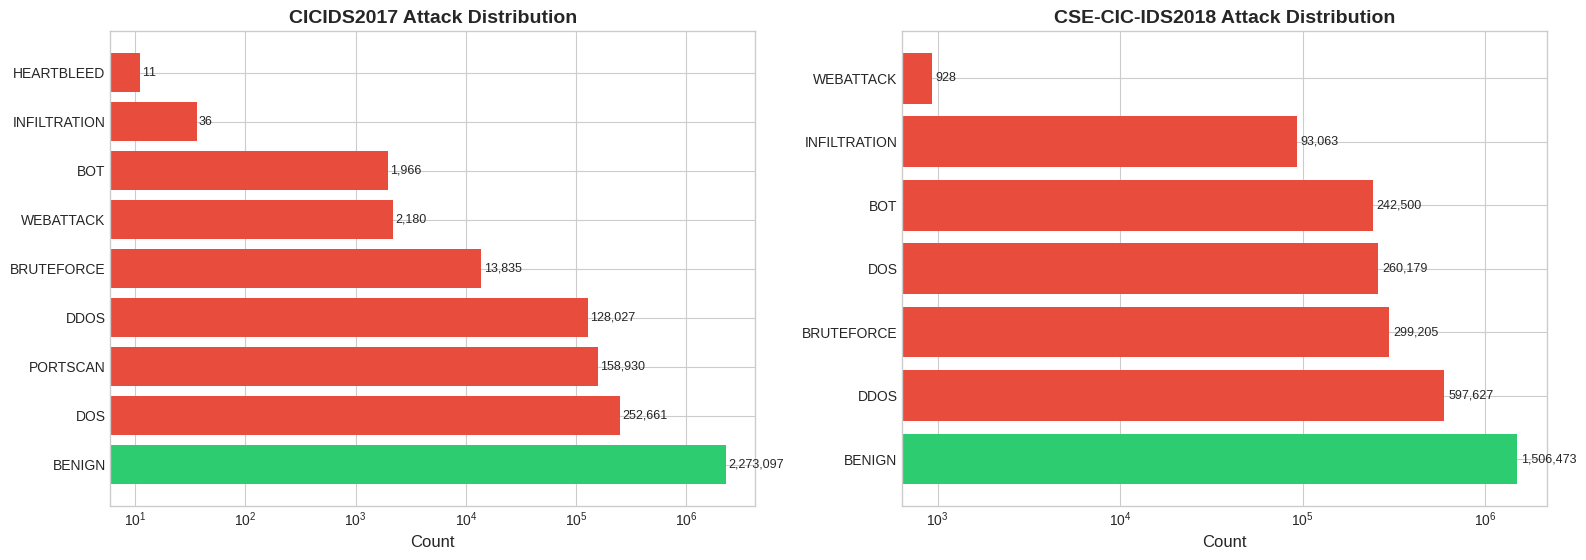

In [11]:
data_2017['Attack_label'] = le.inverse_transform(data_2017['Attack_type'].astype(int))
data_2018['Attack_label'] = le.inverse_transform(data_2018['Attack_type'].astype(int))
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
attack_counts_2017 = data_2017['Attack_label'].value_counts()
attack_counts_2017.index = attack_counts_2017.index.astype(str)
colors_2017 = ['#2ecc71' if x.strip().upper() == 'BENIGN' else '#e74c3c' for x in attack_counts_2017.index]
bars1 = axes[0].barh(attack_counts_2017.index, attack_counts_2017.values, color=colors_2017)
axes[0].set_xlabel('Count', fontsize=12)
axes[0].set_title('CICIDS2017 Attack Distribution', fontsize=14, fontweight='bold')
axes[0].set_xscale('log')
for bar, count in zip(bars1, attack_counts_2017.values):
    axes[0].text(count*1.05, bar.get_y() + bar.get_height()/2, f'{count:,}', va='center', fontsize=9)
attack_counts_2018 = data_2018['Attack_label'].value_counts()
attack_counts_2018.index = attack_counts_2018.index.astype(str)
colors_2018 = ['#2ecc71' if x.strip().upper() == 'BENIGN' else '#e74c3c' for x in attack_counts_2018.index]
bars2 = axes[1].barh(attack_counts_2018.index, attack_counts_2018.values, color=colors_2018)
axes[1].set_xlabel('Count', fontsize=12)
axes[1].set_title('CSE-CIC-IDS2018 Attack Distribution', fontsize=14, fontweight='bold')
axes[1].set_xscale('log')
for bar, count in zip(bars2, attack_counts_2018.values):
    axes[1].text(count*1.05, bar.get_y() + bar.get_height()/2, f'{count:,}', va='center', fontsize=9)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('attack_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# 8.2 FEATURE DISTRIBUTIONS (BATCH)

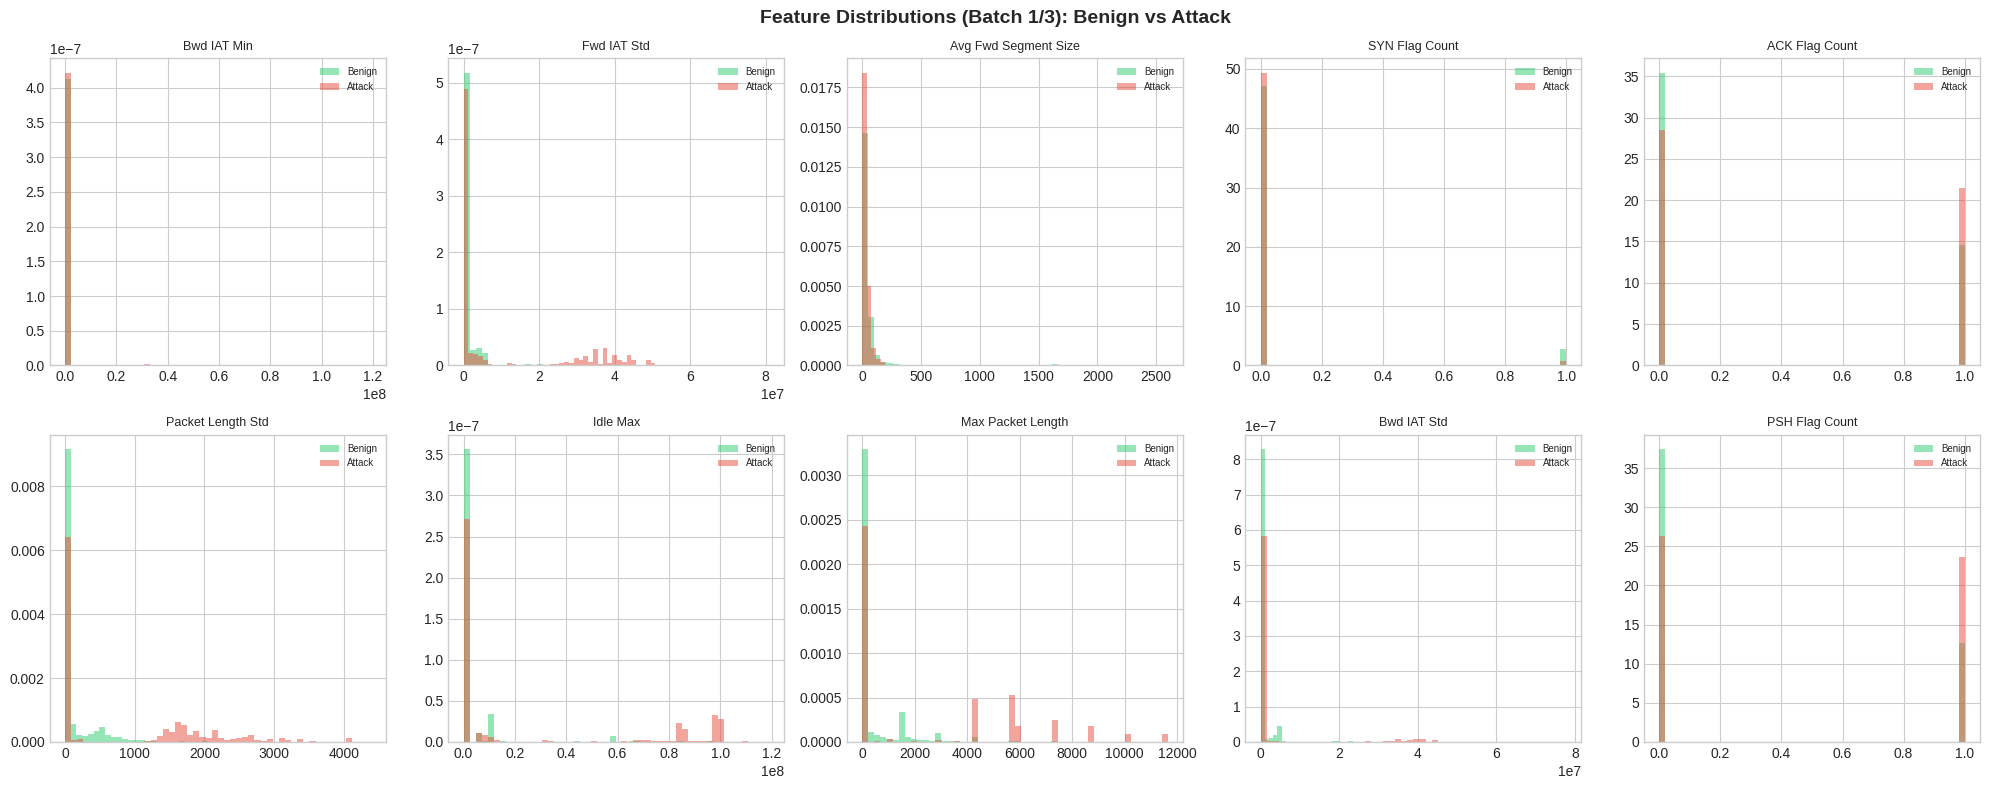

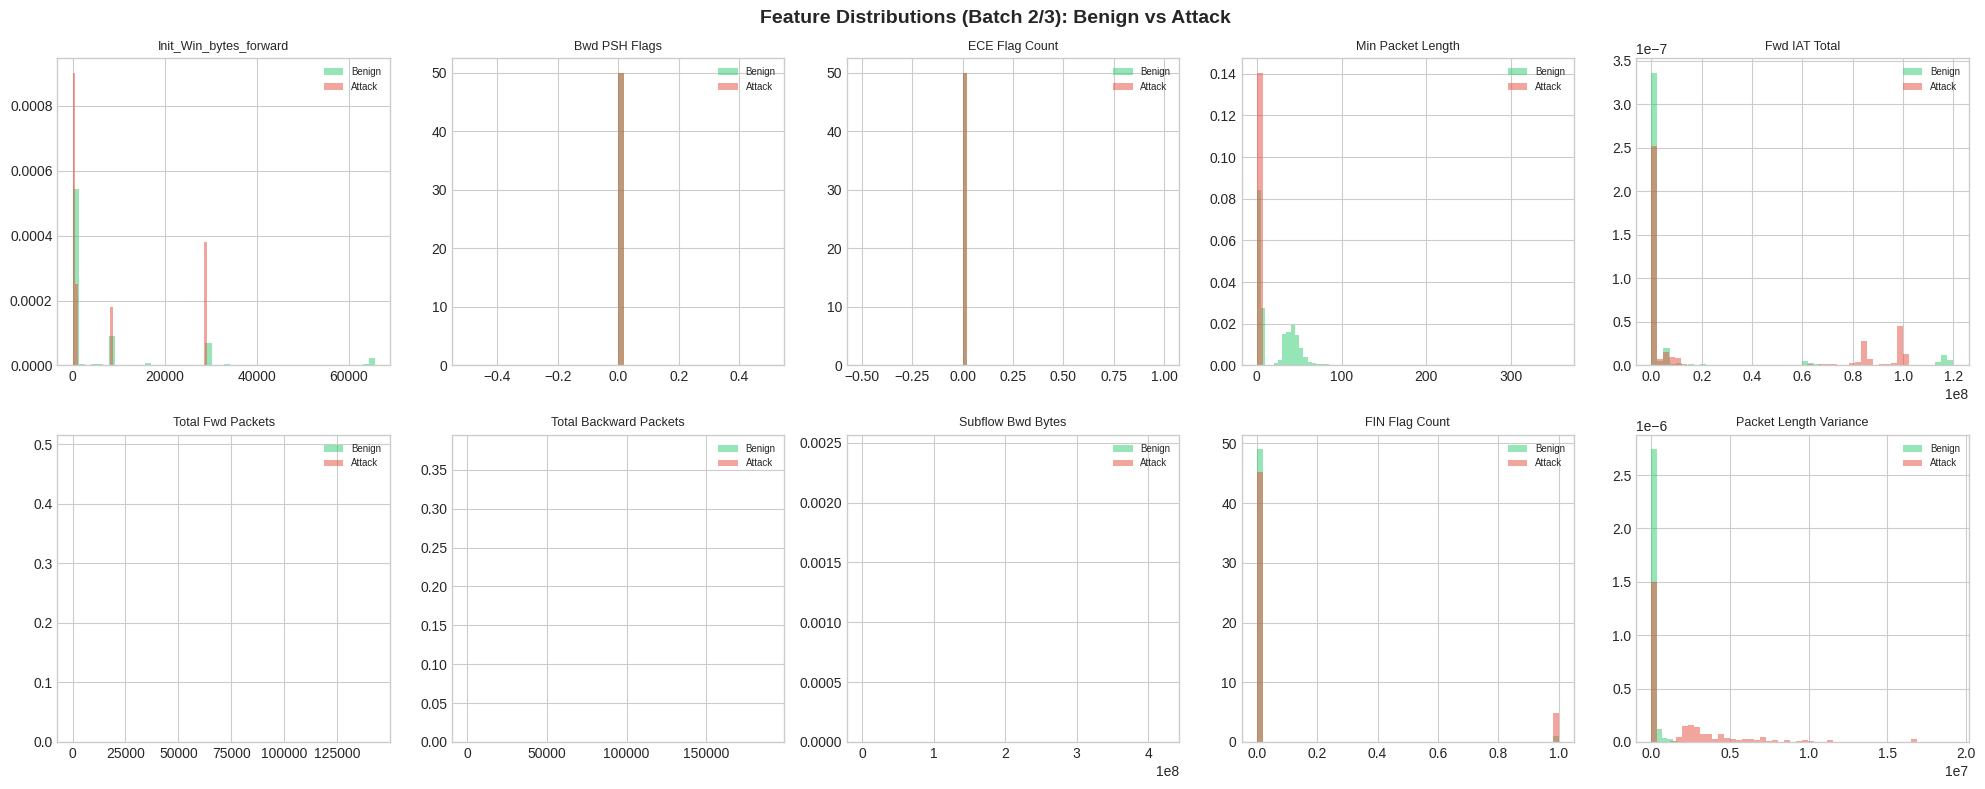

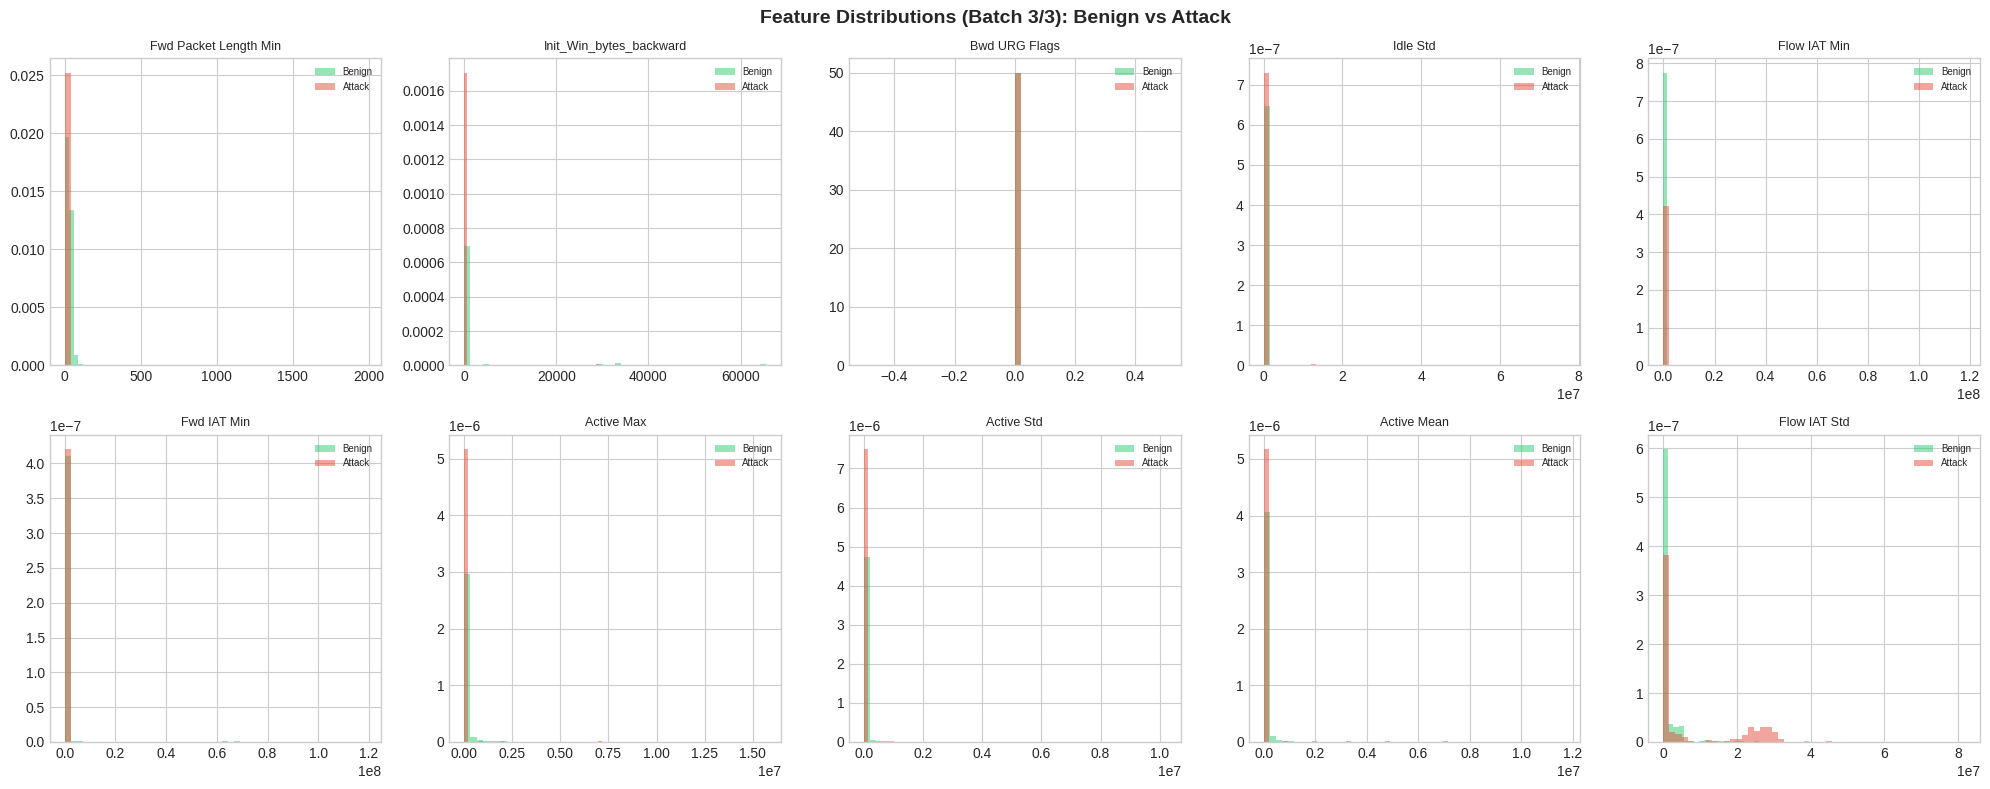

In [12]:
def clean_numeric_data(df, cols):
    df_clean = df[cols].copy()
    df_clean = df_clean.replace([np.inf, -np.inf], np.nan)
    df_clean = df_clean.fillna(df_clean.median())
    return df_clean
subset_cols = numeric_cols[:30]
viz_data_2017 = clean_numeric_data(eda_sample_2017, subset_cols)
batch_size = 10
num_batches = (len(subset_cols) + batch_size - 1) // batch_size
for batch_idx in range(num_batches):
    start_idx = batch_idx * batch_size
    end_idx = min((batch_idx + 1) * batch_size, len(subset_cols))
    batch_cols = subset_cols[start_idx:end_idx]
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()
    for i, col in enumerate(batch_cols):
        ax = axes[i]
        benign_data = viz_data_2017[eda_sample_2017['Attack_binary'] == 0][col]
        attack_data = viz_data_2017[eda_sample_2017['Attack_binary'] == 1][col]
        if len(benign_data) == 0 and len(attack_data) == 0:
            ax.set_visible(False)
            continue
        benign_sample = benign_data.sample(min(5000, len(benign_data)), random_state=RANDOM_STATE)
        attack_sample = attack_data.sample(min(5000, len(attack_data)), random_state=RANDOM_STATE)
        ax.hist(benign_sample, bins=50, alpha=0.5, label='Benign', color='#2ecc71', density=True)
        ax.hist(attack_sample, bins=50, alpha=0.5, label='Attack', color='#e74c3c', density=True)
        ax.set_title(col[:25], fontsize=9)
        ax.legend(fontsize=7)
    plt.suptitle(f'Feature Distributions (Batch {batch_idx+1}/{num_batches}): Benign vs Attack',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'feature_distributions_batch_{batch_idx+1}.png', dpi=100, bbox_inches='tight')
    plt.show()

# 8.3 CORRELATION HEATMAP

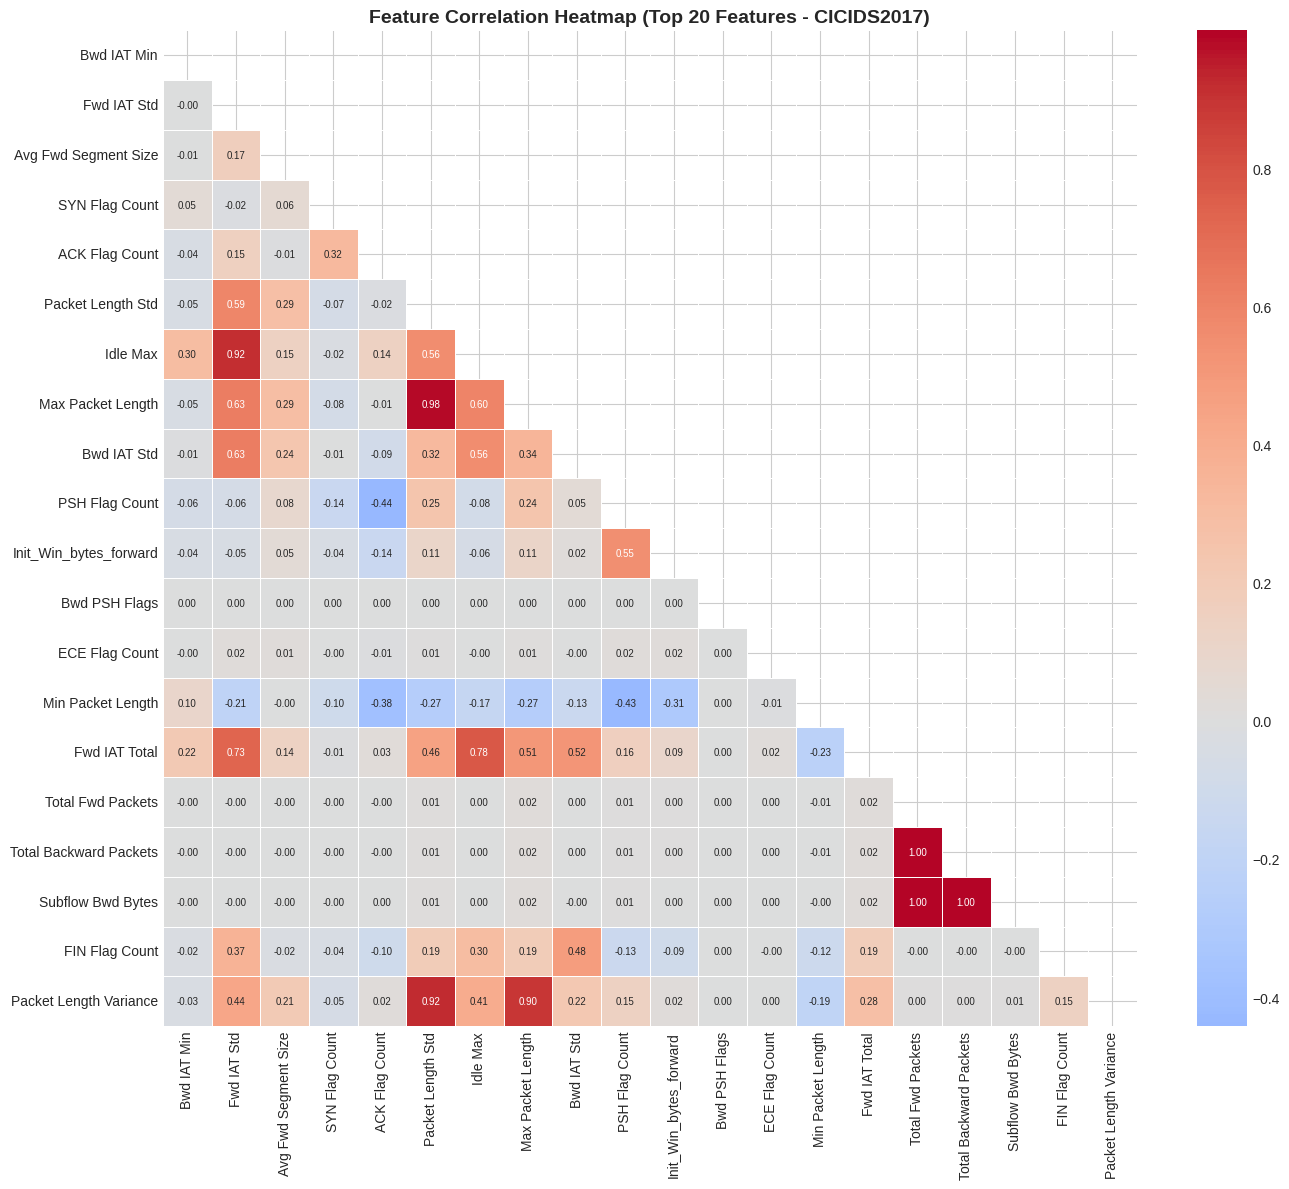

In [13]:
top_corr_cols = numeric_cols[:20]
corr_data_2017 = clean_numeric_data(eda_sample_2017, top_corr_cols)
corr_matrix = corr_data_2017.corr().fillna(0)
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    center=0, 
    linewidths=0.5,
    annot_kws={'size': 7}
)
plt.title('Feature Correlation Heatmap (Top 20 Features - CICIDS2017)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# 8.4 FEATURE VARIANCE ANALYSIS 


Computing feature variance on scaled data


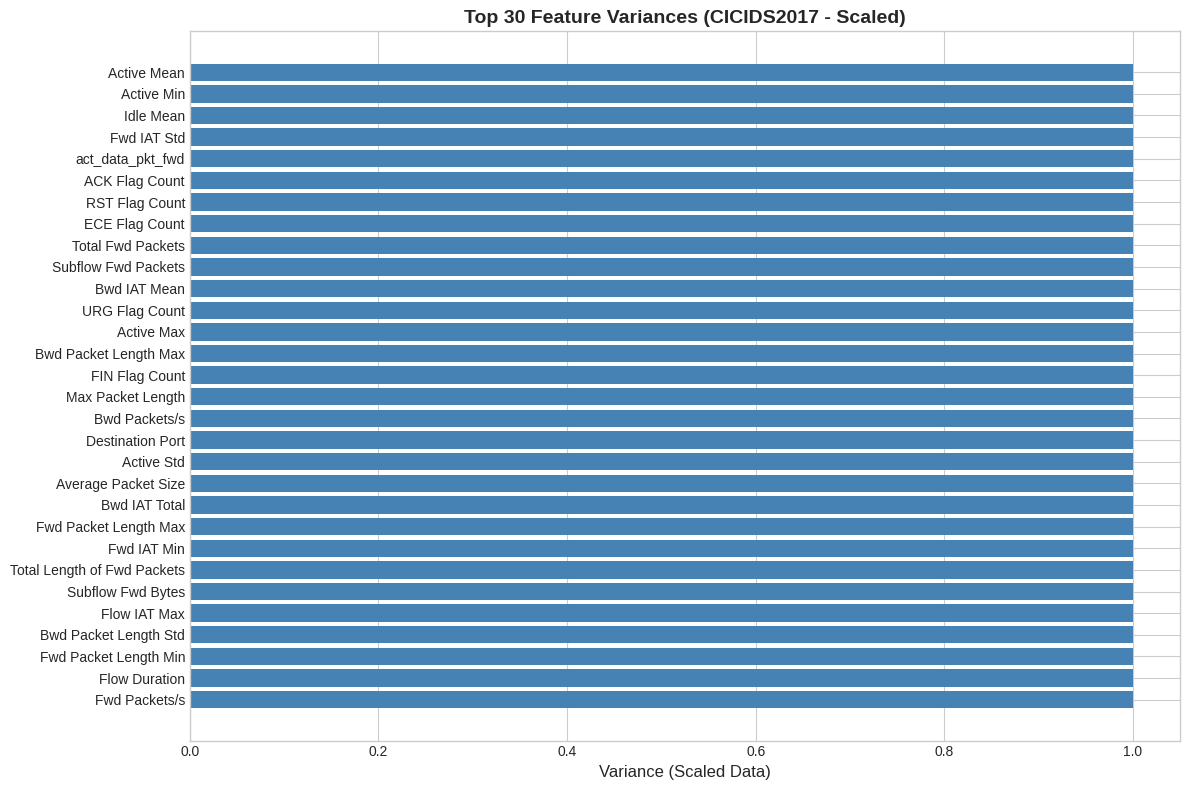

Feature variance plot saved (using scaled data)


In [14]:
print("\nComputing feature variance on scaled data")
viz_clean = clean_numeric_data(eda_sample_2017, numeric_cols)
scaler_viz = StandardScaler()
scaled_viz = scaler_viz.fit_transform(viz_clean)
scaled_viz_df = pd.DataFrame(scaled_viz, columns=numeric_cols)
feature_variances = scaled_viz_df.var().sort_values(ascending=False)
plt.figure(figsize=(12, 8))
top_vars = feature_variances.head(30)
bars = plt.barh(range(len(top_vars)), top_vars.values, color='steelblue')
plt.yticks(range(len(top_vars)), top_vars.index)
plt.xlabel('Variance (Scaled Data)', fontsize=12)
plt.title('Top 30 Feature Variances (CICIDS2017 - Scaled)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_variances.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature variance plot saved (using scaled data)")

# =============================================================================
# 9. DATA PREPROCESSING FOR MODELING 
# =============================================================================
* Preprocesses features: keeps numeric columns, replaces ±∞ with NaN, imputes medians, and casts to float32.
* Builds X/y for 2017 and 2018 using Attack_binary as the target; prints shapes and class distributions.
* Aligns schemas: finds common feature names across years, subsets & sorts columns to ensure identical feature order.
* Confirms final aligned shapes for both feature sets.

In [15]:
print("DATA PREPROCESSING")
def prepare_data(df, feature_cols, target_col='Attack_binary'):
    X = df[feature_cols].copy()
    X = X.select_dtypes(include=[np.number])
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median())
    X = X.astype('float32')
    y = df[target_col].copy()
    return X, y

X_2017, y_2017 = prepare_data(data_2017, feature_cols)
X_2018, y_2018 = prepare_data(data_2018, feature_cols)
print(f"2017 Features Shape: {X_2017.shape}")
print(f"2017 Target Shape: {y_2017.shape}")
print(f"\n2018 Features Shape: {X_2018.shape}")
print(f"2018 Target Shape: {y_2018.shape}")
print("\n2017 Class Distribution:")
print(y_2017.value_counts())
print("\n2018 Class Distribution:")
print(y_2018.value_counts())

DATA PREPROCESSING
2017 Features Shape: (2830743, 71)
2017 Target Shape: (2830743,)

2018 Features Shape: (2999975, 71)
2018 Target Shape: (2999975,)

2017 Class Distribution:
Attack_binary
0    2273097
1     557646
Name: count, dtype: int64

2018 Class Distribution:
Attack_binary
0    1506473
1    1493502
Name: count, dtype: int64


# ALIGN FEATURES BETWEEN 2017 AND 2018

In [16]:
common_features = list(set(X_2017.columns).intersection(set(X_2018.columns)))
print("Common features:", len(common_features))
X_2017 = X_2017[common_features].copy()
X_2018 = X_2018[common_features].copy()
X_2017 = X_2017.sort_index(axis=1)
X_2018 = X_2018.sort_index(axis=1)
print("2017 shape after alignment:", X_2017.shape)
print("2018 shape after alignment:", X_2018.shape)

Common features: 71
2017 shape after alignment: (2830743, 71)
2018 shape after alignment: (2999975, 71)


# =============================================================================
# 10. FEATURE SELECTION (FIXED ORDER: Scale -> Variance -> ANOVA)
# =============================================================================
* Scales features with StandardScaler and removes low-variance ones using VarianceThreshold(0.01).
* Runs ANOVA (SelectKBest, k=30) on scaled high‑variance features, plots top scores, and lists selected features.
* Performs PCA on selected features, chooses components to reach 95% explained variance, and transforms 2017/2018 data.
* Visualizes PCA: cumulative variance curve and a 2D scatter (PC1 vs PC2) colored by class; saves plots to files.

FEATURE SELECTION (FIXED ORDER)

Scaling features first...

Removing low variance features...
   High variance features: 69

Performing ANOVA feature selection on scaled data...
   Top 30 ANOVA features selected


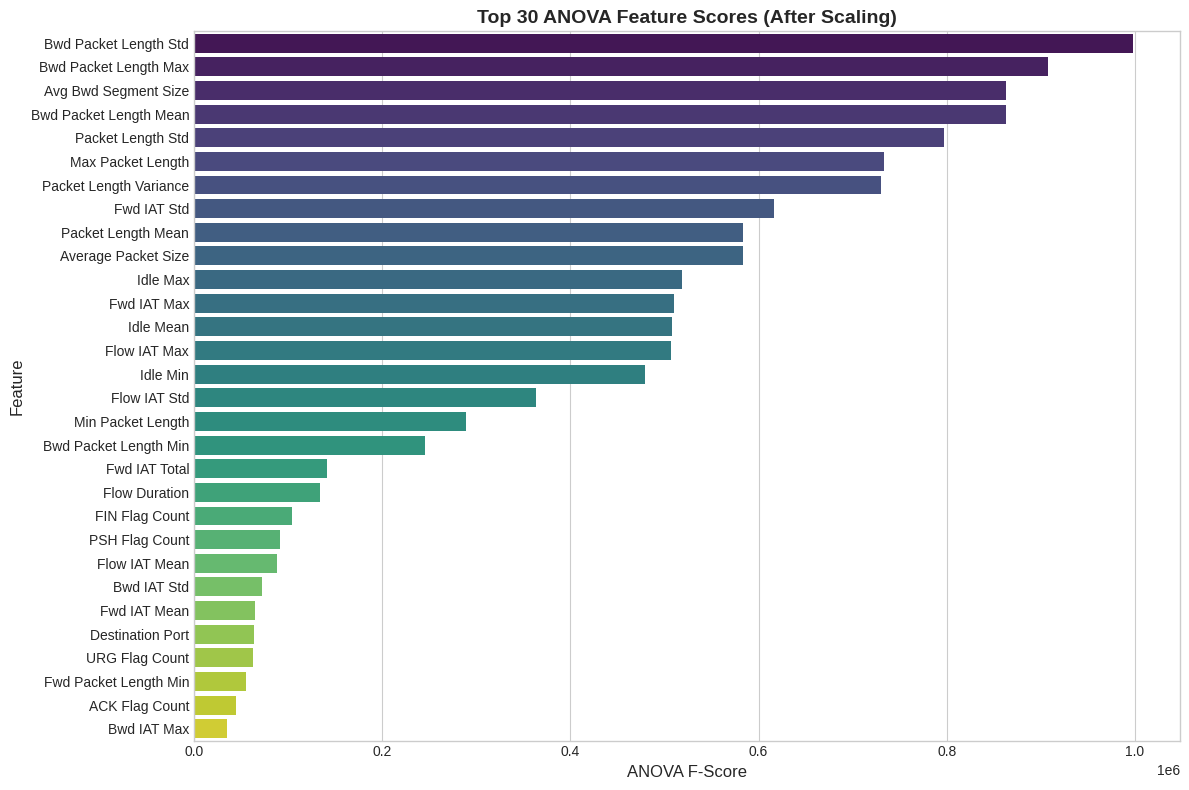


Selected ANOVA Features:
  1. ACK Flag Count
  2. Average Packet Size
  3. Avg Bwd Segment Size
  4. Bwd IAT Max
  5. Bwd IAT Std
  6. Bwd Packet Length Max
  7. Bwd Packet Length Mean
  8. Bwd Packet Length Min
  9. Bwd Packet Length Std
  10. Destination Port
  ...


In [17]:
print("FEATURE SELECTION (FIXED ORDER)")
print("\nScaling features first...")
scaler = StandardScaler()
X_2017_scaled = scaler.fit_transform(X_2017)
X_2018_scaled = scaler.transform(X_2018)
X_2017_scaled_df = pd.DataFrame(X_2017_scaled, columns=X_2017.columns)
X_2018_scaled_df = pd.DataFrame(X_2018_scaled, columns=X_2018.columns)
print("\nRemoving low variance features...")
var_selector = VarianceThreshold(threshold=0.01)
X_2017_var = var_selector.fit_transform(X_2017_scaled_df)
selected_mask = var_selector.get_support()
high_var_features = X_2017.columns[selected_mask].tolist()
print(f"   High variance features: {len(high_var_features)}")
print("\nPerforming ANOVA feature selection on scaled data...")
k_anova = 30
anova_selector = SelectKBest(score_func=f_classif, k=k_anova)
X_2017_anova = anova_selector.fit_transform(X_2017_scaled_df[high_var_features], y_2017)
anova_features = np.array(high_var_features)[anova_selector.get_support()].tolist()
print(f"   Top {k_anova} ANOVA features selected")
plt.figure(figsize=(12, 8))
anova_scores = pd.DataFrame({
    'Feature': high_var_features,
    'Score': anova_selector.scores_
}).sort_values('Score', ascending=False).head(30)
sns.barplot(data=anova_scores, x='Score', y='Feature', palette='viridis')
plt.title('Top 30 ANOVA Feature Scores (After Scaling)', fontsize=14, fontweight='bold')
plt.xlabel('ANOVA F-Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.savefig('anova_feature_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSelected ANOVA Features:")
for i, feat in enumerate(anova_features[:10]):
    print(f"  {i+1}. {feat}")
print("  ...")

# =============================================================================
# 10.1 PCA DIMENSIONALITY REDUCTION 
# =============================================================================


PCA DIMENSIONALITY REDUCTION


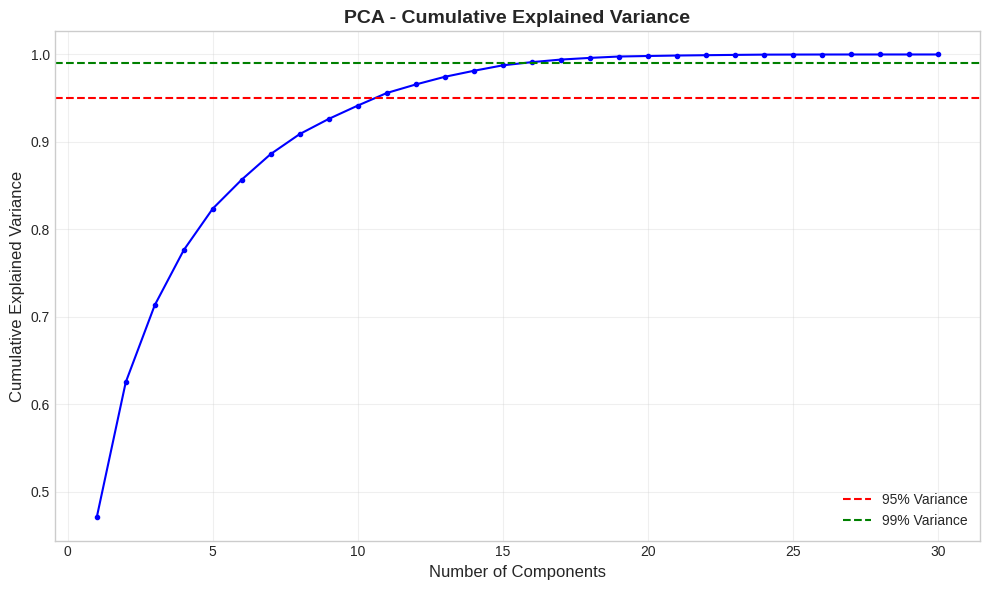


Components for 95% variance: 11
Components for 99% variance: 16

Using 11 components (95% variance threshold)

PCA applied: 30 → 11 components
Explained variance: 0.9560


In [18]:
print("PCA DIMENSIONALITY REDUCTION")
X_2017_anova_scaled = X_2017_scaled_df[anova_features].values
X_2018_anova_scaled = X_2018_scaled_df[anova_features].values
pca_full = PCA()
pca_full.fit(X_2017_anova_scaled)
plt.figure(figsize=(10, 6))
cumsum = np.cumsum(pca_full.explained_variance_ratio_)
plt.plot(range(1, len(cumsum)+1), cumsum, 'b-o', markersize=3)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.axhline(y=0.99, color='g', linestyle='--', label='99% Variance')
plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance', fontsize=12)
plt.title('PCA - Cumulative Explained Variance', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pca_variance_explained.png', dpi=150, bbox_inches='tight')
plt.show()
n_components_95 = np.argmax(cumsum >= 0.95) + 1
n_components_99 = np.argmax(cumsum >= 0.99) + 1
print(f"\nComponents for 95% variance: {n_components_95}")
print(f"Components for 99% variance: {n_components_99}")
N_COMPONENTS = n_components_95
print(f"\nUsing {N_COMPONENTS} components (95% variance threshold)")
pca = PCA(n_components=N_COMPONENTS)
X_2017_pca = pca.fit_transform(X_2017_anova_scaled)
X_2018_pca = pca.transform(X_2018_anova_scaled)
print(f"\nPCA applied: {X_2017_anova_scaled.shape[1]} → {N_COMPONENTS} components")
print(f"Explained variance: {sum(pca.explained_variance_ratio_):.4f}")

# 10.2 PCA PROJECTION VISUALIZATION (NEW)


Creating PCA projection visualization...


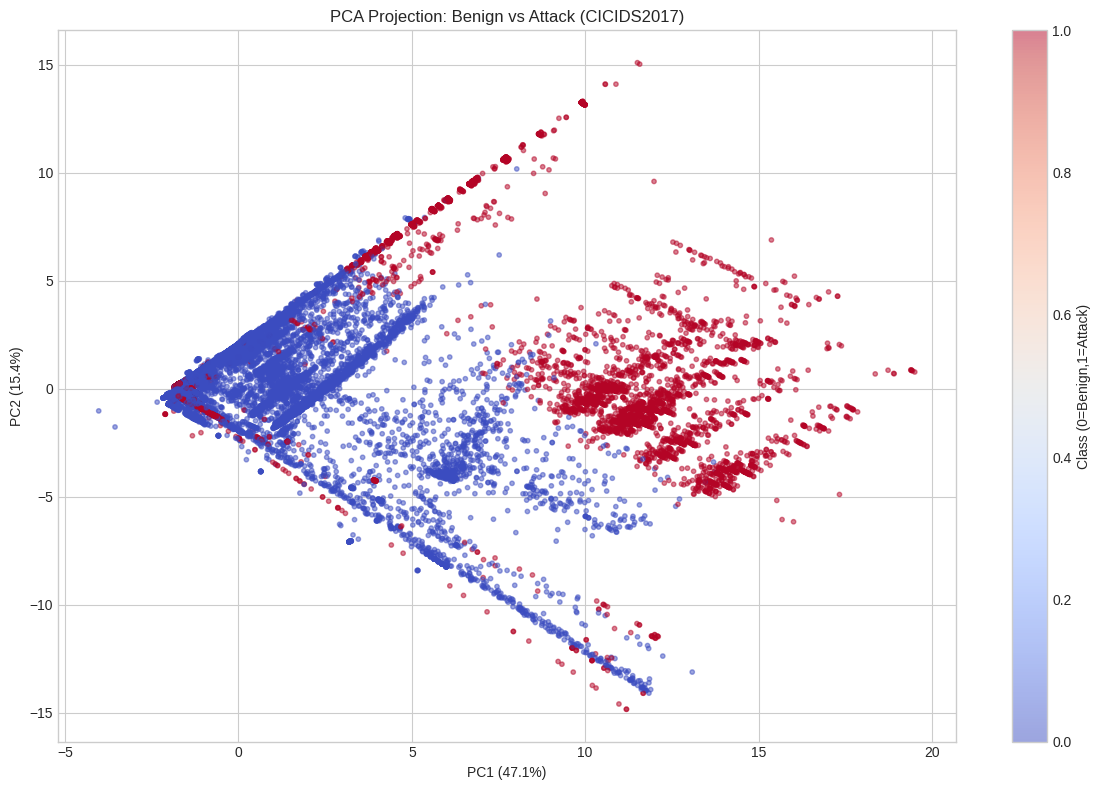

In [19]:
print("\nCreating PCA projection visualization...")

if X_2017_pca.shape[1] < 2:
    print("PCA has only 1 component — cannot create 2D plot.")
else:
    sample_size = min(50000, len(X_2017_pca))
    sample_idx = np.random.choice(len(X_2017_pca), sample_size, replace=False)
    X_pca_sample = X_2017_pca[sample_idx]
    y_pca_sample = y_2017.values[sample_idx]
    plt.figure(figsize=(12,8))
    scatter = plt.scatter(
        X_pca_sample[:,0],
        X_pca_sample[:,1],
        c=y_pca_sample,
        cmap='coolwarm',
        alpha=0.5,
        s=10
    )
    plt.colorbar(scatter,label='Class (0=Benign,1=Attack)')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    plt.title('PCA Projection: Benign vs Attack (CICIDS2017)')

    plt.tight_layout()
    plt.show()

# =============================================================================
# 11. TRAIN-VALIDATION SPLIT (2017 DATA)
# =============================================================================

In [20]:
print("TRAIN-VALIDATION SPLIT")
X_train_2017, X_val_2017, y_train_2017, y_val_2017 = train_test_split(
    X_2017_pca, 
    y_2017, 
    test_size=0.2, 
    stratify=y_2017, 
    random_state=RANDOM_STATE
)
print(f"Training set (2017): {X_train_2017.shape}")
print(f"Validation set (2017): {X_val_2017.shape}")
print(f"\nTraining class distribution:")
print(pd.Series(y_train_2017).value_counts())
X_full_2017 = X_2017_pca
y_full_2017 = y_2017

TRAIN-VALIDATION SPLIT
Training set (2017): (2264594, 11)
Validation set (2017): (566149, 11)

Training class distribution:
Attack_binary
0    1818477
1     446117
Name: count, dtype: int64


# =============================================================================
# 12. MODEL DEFINITIONS 
# =============================================================================

In [21]:
print("MODEL TRAINING AND COMPARISON")
pos = (y_2017 == 1).sum()
neg = (y_2017 == 0).sum()
xgb_scale_pos_weight = neg / max(pos, 1)
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight='balanced'
    ),
    'Decision Tree': DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        class_weight='balanced'
    )
}
if XGB_AVAILABLE:
    models['XGBoost (CPU)'] = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        scale_pos_weight=xgb_scale_pos_weight,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        eval_metric='logloss',
        tree_method='hist',       
        predictor='cpu_predictor')
if LGB_AVAILABLE:
    models['LightGBM (CPU)'] = lgb.LGBMClassifier(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        class_weight='balanced',
        num_leaves=255,      
        subsample=0.8,
        colsample_bytree=0.8,
        device='cpu'  
    )
print(f"Models to compare: {list(models.keys())}")

MODEL TRAINING AND COMPARISON
Models to compare: ['Logistic Regression', 'Decision Tree', 'XGBoost (CPU)', 'LightGBM (CPU)']


# =============================================================================
# 13. CROSS-VALIDATION ON 2017 (STAGE 1: BINARY CLASSIFICATION)
# =============================================================================
* Sets up Stage 1 binary classification (Benign vs Attack) using 5-fold StratifiedKFold to preserve class balance in each split.
* Loops through each model and runs cross-validation on the 2017 training set (X_train_2017, y_train_2017) using accuracy as the scoring metric.
* Collects mean and standard deviation of CV accuracy for each model and prints per-model results.
* Builds a results DataFrame, sorts by best mean accuracy, and prints the final CV leaderboard for 2017.

In [22]:
warnings.filterwarnings("ignore")
os.environ["PYTHONWARNINGS"] = "ignore" 
print("STAGE 1: BINARY CLASSIFICATION (Benign vs Attack)")
kfold = StratifiedKFold(n_splits=2, shuffle=True, random_state=RANDOM_STATE)
cv_results = []

for name, model in models.items():
    print(f"\nCross-validating {name}...")
    cv_scores = cross_val_score(
        model, X_train_2017, y_train_2017, 
        cv=kfold, scoring='accuracy', n_jobs=-1
    )
    cv_results.append({
        'Model': name,
        'CV Accuracy Mean': cv_scores.mean(),
        'CV Accuracy Std': cv_scores.std()
    })
    
    print(f"  CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
cv_df = pd.DataFrame(cv_results).sort_values('CV Accuracy Mean', ascending=False)
print("CROSS-VALIDATION RESULTS (2017)")
print(cv_df.to_string(index=False))

STAGE 1: BINARY CLASSIFICATION (Benign vs Attack)

Cross-validating Logistic Regression...
  CV Accuracy: 0.7823 (+/- 0.0002)

Cross-validating Decision Tree...
  CV Accuracy: 0.9965 (+/- 0.0000)

Cross-validating XGBoost (CPU)...
  CV Accuracy: 0.9874 (+/- 0.0000)

Cross-validating LightGBM (CPU)...
[LightGBM] [Info] Number of positive: 223058, number of negative: 909239
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.142931 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2805
[LightGBM] [Info] Number of data points in the train set: 1132297, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

# =============================================================================
# 14. TRAIN AND EVALUATE MODELS ON VALIDATION SET (2017)
# =============================================================================
* Trains each model on the full 2017 training split (X_train_2017, y_train_2017) and records training time.
* Evaluates on the 2017 validation set (X_val_2017, y_val_2017) using key metrics: Accuracy, Precision, Recall, F1, plus ROC‑AUC (if predict_proba exists).
* Computes the confusion matrix and derives False Positive Rate (FPR) from it to measure benign→attack false alarms.
* Stores all metrics into a results list, converts to a DataFrame, sorts by best F1‑Score, and prints the validation leaderboard.


In [23]:
warnings.filterwarnings("ignore")
os.environ["PYTHONWARNINGS"] = "ignore" 
print("VALIDATION SET PERFORMANCE (2017)")
validation_results = []
trained_models = {}
for name, model in models.items():
    print(f"\nTraining {name} on full training set.")
    start_time = time.time()
    model.fit(X_train_2017, y_train_2017)
    train_time = time.time() - start_time
    trained_models[name] = model
    y_val_pred = model.predict(X_val_2017)
    acc = accuracy_score(y_val_2017, y_val_pred)
    prec = precision_score(y_val_2017, y_val_pred)
    rec = recall_score(y_val_2017, y_val_pred)
    f1 = f1_score(y_val_2017, y_val_pred)
    try:
        y_val_prob = model.predict_proba(X_val_2017)[:, 1]
        roc_auc = roc_auc_score(y_val_2017, y_val_prob)
    except AttributeError:
        roc_auc = 0.0
    cm = confusion_matrix(y_val_2017, y_val_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    validation_results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'FPR': fpr,
        'Train Time (s)': train_time
    })    
    print(f"  Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}, FPR: {fpr:.4f}")
val_df = pd.DataFrame(validation_results).sort_values('F1-Score', ascending=False)
print("\nVALIDATION RESULTS 2017")
print(val_df.to_string(index=False))

VALIDATION SET PERFORMANCE (2017)

Training Logistic Regression on full training set.
  Accuracy: 0.7821, Precision: 0.4735, Recall: 0.9490, F1: 0.6318, FPR: 0.2589

Training Decision Tree on full training set.
  Accuracy: 0.9968, Precision: 0.9889, Recall: 0.9947, F1: 0.9918, FPR: 0.0027

Training XGBoost (CPU) on full training set.
  Accuracy: 0.9879, Precision: 0.9444, Recall: 0.9971, F1: 0.9700, FPR: 0.0144

Training LightGBM (CPU) on full training set.
[LightGBM] [Info] Number of positive: 446117, number of negative: 1818477
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.138927 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2805
[LightGBM] [Info] Number of data points in the train set: 2264594, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits wi

# =============================================================================
# 15. VISUALIZE MODEL COMPARISON
# =============================================================================


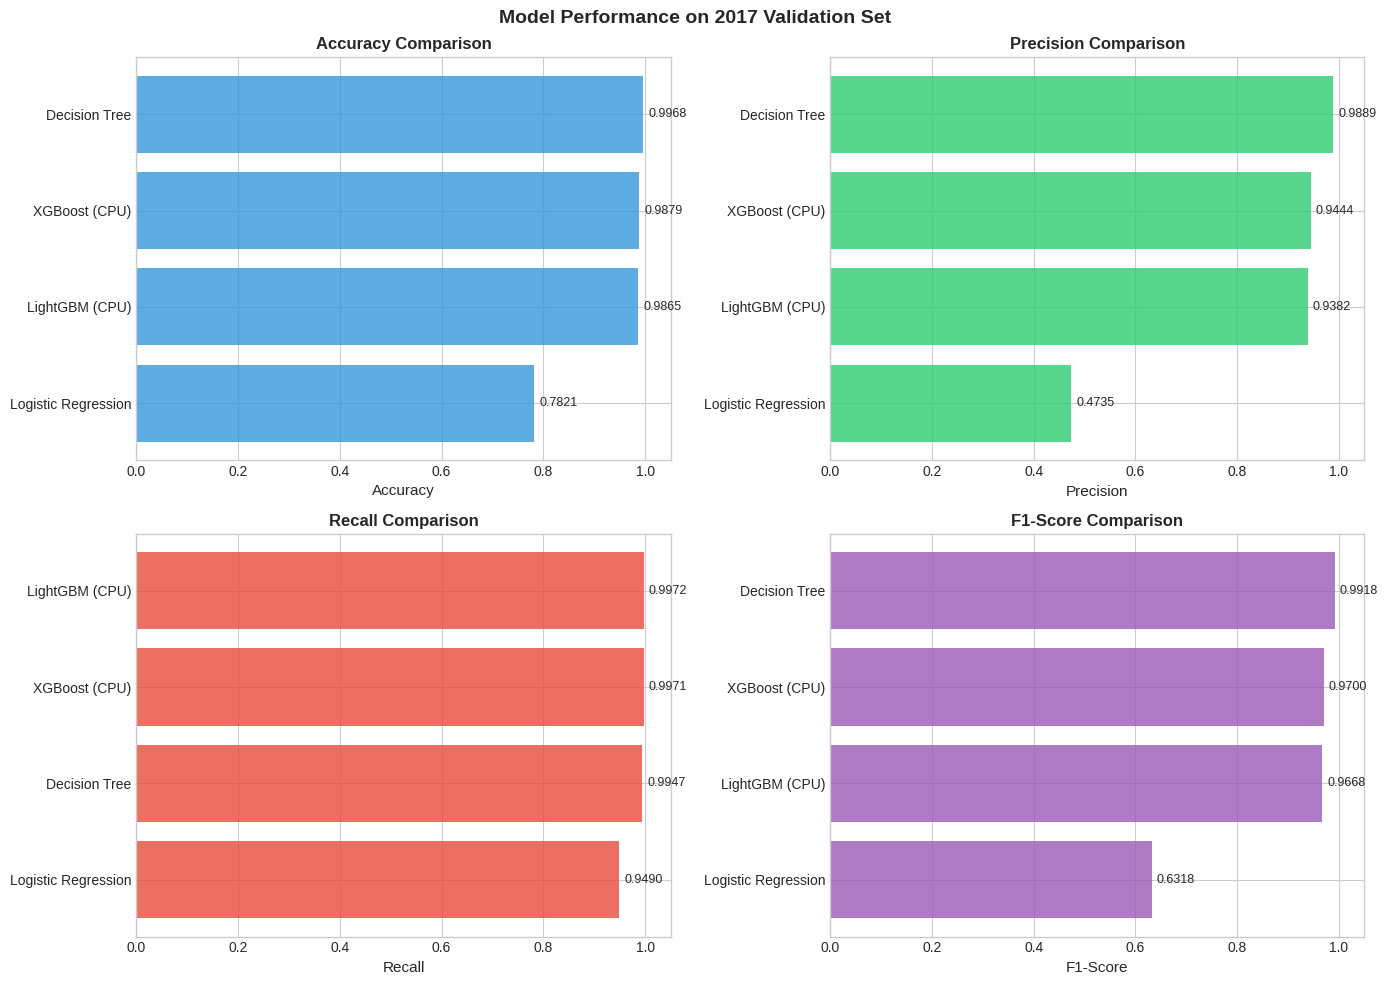

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
for idx, (metric, color) in enumerate(zip(metrics, colors)):
    ax = axes[idx // 2, idx % 2]
    sorted_df = val_df.sort_values(metric, ascending=True)
    bars = ax.barh(sorted_df['Model'], sorted_df[metric], color=color, alpha=0.8)
    ax.set_xlabel(metric, fontsize=11)
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1.05)
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{val:.4f}', va='center', fontsize=9)
plt.suptitle('Model Performance on 2017 Validation Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison_validation.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# 16. SELECT BEST MODEL AND EVALUATE ON 2018 (TEST SET)
# =============================================================================
* Selects the best model from val_df (top row, highest validation performance) and retrieves the already trained instance from trained_models.
* Tests on unseen 2018 data (X_2018_pca, y_2018) and computes Accuracy, Precision, Recall, F1, ROC‑AUC (if proba available) plus FPR from the confusion matrix.
* Plots confusion matrices side‑by‑side for 2017 validation vs 2018 test, saves as confusion_matrices.png.
* Plots ROC curves side‑by‑side for 2017 validation and 2018 test (with AUC in legend), saves as roc_curves.png.

In [25]:
import os
save_dir = "/kaggle/working"
from datetime import datetime
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
# Make sure it exists (optional, usually /kaggle/working exists)
os.makedirs(save_dir, exist_ok=True)

In [26]:
test_results = {}
print("TEST ON 2018 DATASET (UNSEEN)\n")
for model_name, model in trained_models.items():
    print(f"Testing model: {model_name}")
    y_pred = model.predict(X_2018_pca)
    acc = accuracy_score(y_2018, y_pred)
    prec = precision_score(y_2018, y_pred)
    rec = recall_score(y_2018, y_pred)
    f1 = f1_score(y_2018, y_pred)
    try:
        y_prob = model.predict_proba(X_2018_pca)[:, 1]
        roc_auc = roc_auc_score(y_2018, y_prob)
    except:
        roc_auc = 0.0
    cm = confusion_matrix(y_2018, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    test_results[model_name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": roc_auc,
        "FPR": fpr
    }
    print(f" Accuracy:  {acc:.4f}")
    print(f" Precision: {prec:.4f}")
    print(f" Recall:    {rec:.4f}")
    print(f" F1-Score:  {f1:.4f}")
    print(f" ROC-AUC:   {roc_auc:.4f}")
    print(f" FPR:       {fpr:.4f}\n")
best_model_name = max(test_results, key=lambda x: test_results[x]["F1-Score"])
best_model = trained_models[best_model_name]
print(f"\nBest model on 2018 dataset: {best_model_name}")
print(f"Metrics: {test_results[best_model_name]}")

TEST ON 2018 DATASET (UNSEEN)

Testing model: Logistic Regression
 Accuracy:  0.7582
 Precision: 0.6928
 Recall:    0.9242
 F1-Score:  0.7919
 ROC-AUC:   0.7985
 FPR:       0.4063

Testing model: Decision Tree
 Accuracy:  0.5518
 Precision: 0.7510
 Recall:    0.1492
 F1-Score:  0.2490
 ROC-AUC:   0.5436
 FPR:       0.0491

Testing model: XGBoost (CPU)
 Accuracy:  0.6630
 Precision: 0.8597
 Recall:    0.3861
 F1-Score:  0.5329
 ROC-AUC:   0.8037
 FPR:       0.0625

Testing model: LightGBM (CPU)
 Accuracy:  0.6603
 Precision: 0.8687
 Recall:    0.3743
 F1-Score:  0.5231
 ROC-AUC:   0.7816
 FPR:       0.0561


Best model on 2018 dataset: Logistic Regression
Metrics: {'Accuracy': 0.7582113184276535, 'Precision': 0.6927747913247303, 'Recall': 0.9241607979098789, 'F1-Score': 0.7919119452687335, 'ROC-AUC': np.float64(0.7985351846389838), 'FPR': np.float64(0.40630930657237135)}


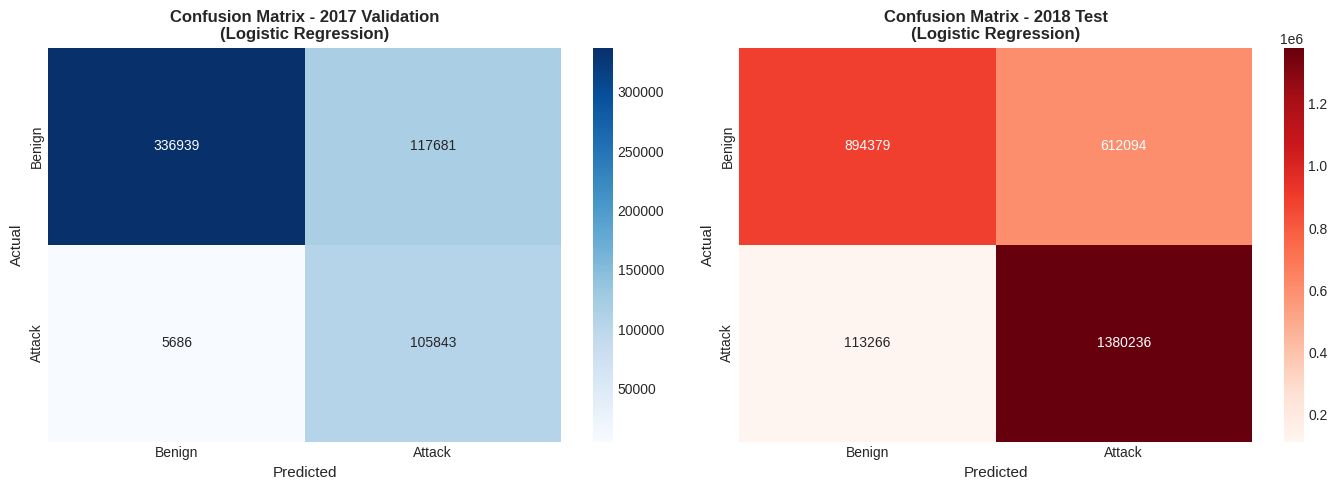

In [27]:
y_val_pred_best = best_model.predict(X_val_2017)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_val = confusion_matrix(y_val_2017, y_val_pred_best)
ax1 = axes[0]
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'])
ax1.set_xlabel('Predicted', fontsize=11)
ax1.set_ylabel('Actual', fontsize=11)
ax1.set_title(f'Confusion Matrix - 2017 Validation\n({best_model_name})', fontsize=12, fontweight='bold')
y_2018_pred = best_model.predict(X_2018_pca) 
cm_test = confusion_matrix(y_2018, y_2018_pred)
ax2 = axes[1]
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Reds', ax=ax2,
            xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'])
ax2.set_xlabel('Predicted', fontsize=11)
ax2.set_ylabel('Actual', fontsize=11)
ax2.set_title(f'Confusion Matrix - 2018 Test\n({best_model_name})', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

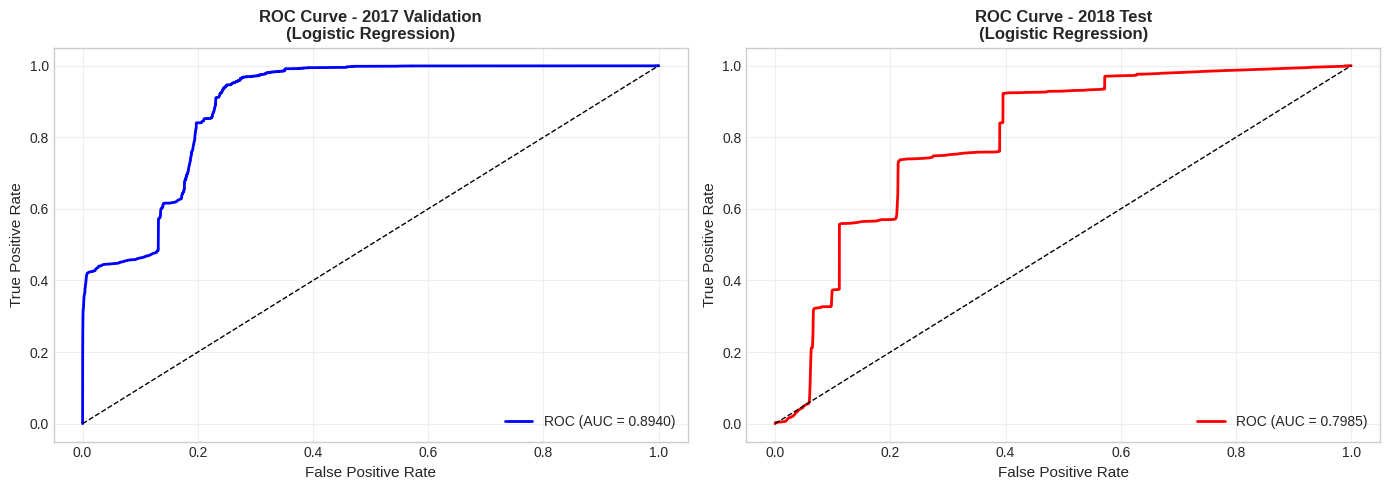

In [28]:
y_val_prob_best = best_model.predict_proba(X_val_2017)[:, 1]
y_2018_prob = best_model.predict_proba(X_2018_pca)[:, 1]  
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax1 = axes[0]
fpr_val, tpr_val, _ = roc_curve(y_val_2017, y_val_prob_best)
auc_val = roc_auc_score(y_val_2017, y_val_prob_best)
ax1.plot(fpr_val, tpr_val, 'b-', linewidth=2, label=f'ROC (AUC = {auc_val:.4f})')
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax1.set_xlabel('False Positive Rate', fontsize=11)
ax1.set_ylabel('True Positive Rate', fontsize=11)
ax1.set_title(f'ROC Curve - 2017 Validation\n({best_model_name})', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)
ax2 = axes[1]
fpr_test, tpr_test, _ = roc_curve(y_2018, y_2018_prob)
auc_test = roc_auc_score(y_2018, y_2018_prob)
ax2.plot(fpr_test, tpr_test, 'r-', linewidth=2, label=f'ROC (AUC = {auc_test:.4f})')
ax2.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax2.set_xlabel('False Positive Rate', fontsize=11)
ax2.set_ylabel('True Positive Rate', fontsize=11)
ax2.set_title(f'ROC Curve - 2018 Test\n({best_model_name})', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# 17. STAGE 2: MULTI-CLASS ATTACK CLASSIFICATION
# =============================================================================


STAGE 2: MULTI-CLASS ATTACK CLASSIFICATION
2017 Attack samples: 557646
2018 Attack samples: 1493502

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

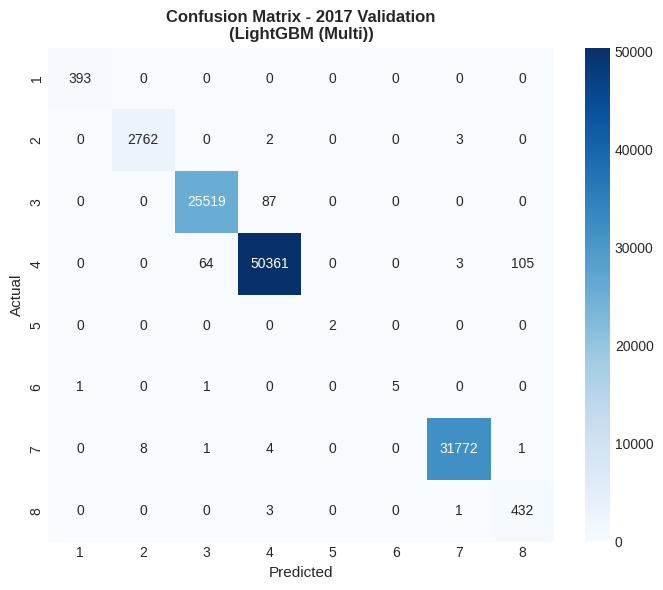

In [29]:
warnings.filterwarnings("ignore")
os.environ["PYTHONWARNINGS"] = "ignore"
print("STAGE 2: MULTI-CLASS ATTACK CLASSIFICATION")
attack_2017 = data_2017[data_2017['Attack_binary'] == 1].copy()
attack_2018 = data_2018[data_2018['Attack_binary'] == 1].copy()
print(f"2017 Attack samples: {len(attack_2017)}")
print(f"2018 Attack samples: {len(attack_2018)}")
X_attack_2017_clean, _ = prepare_data(attack_2017, feature_cols)
y_attack_2017 = attack_2017['Attack_type'].values
X_attack_2017_clean = X_attack_2017_clean[common_features].sort_index(axis=1)
X_attack_2017_scaled = scaler.transform(X_attack_2017_clean)
X_attack_2017_scaled_df = pd.DataFrame(X_attack_2017_scaled,
                                       columns=X_attack_2017_clean.columns)
X_attack_2017_highvar = X_attack_2017_scaled_df[high_var_features].values
X_attack_2017_anova = anova_selector.transform(X_attack_2017_highvar)
X_attack_2017_pca = pca.transform(X_attack_2017_anova)
X_train_att, X_val_att, y_train_att, y_val_att = train_test_split(
    X_attack_2017_pca,
    y_attack_2017,
    test_size=0.2,
    stratify=y_attack_2017,
    random_state=RANDOM_STATE
)
le_attack = LabelEncoder()
y_train_xgb = le_attack.fit_transform(y_train_att)
y_val_xgb = le_attack.transform(y_val_att)
multi_models = {
    "Logistic Regression (Multinomial)": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced",
        multi_class="multinomial"
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced"
    )
}
if 'xgb' in globals():
    multi_models["XGBoost (Multi)"] = xgb.XGBClassifier(
        n_estimators=250,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="multi:softprob",
        num_class=len(np.unique(y_train_xgb)),
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        verbosity=0
    )
if 'lgb' in globals():
    multi_models["LightGBM (Multi)"] = lgb.LGBMClassifier(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        num_leaves=64,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=50,
        min_gain_to_split=0.1,
        objective="multiclass",
        num_class=len(np.unique(y_train_att)),
        verbosity=-1,
        force_col_wise=True
    )
multi_results = []
kfold_multi = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)
for name, model in multi_models.items():
    print(f"\nProcessing {name}...")
    if name in ["Logistic Regression (Multinomial)", "Decision Tree"]:
        cv_f1 = cross_val_score(
            model,
            X_train_att,
            y_train_att,
            cv=kfold_multi,
            scoring="f1_macro",
            n_jobs=-1
        )
        cv_acc = cross_val_score(
            model,
            X_train_att,
            y_train_att,
            cv=kfold_multi,
            scoring="accuracy",
            n_jobs=-1
        )
        print(f"  CV F1-macro: {cv_f1.mean():.4f} (+/- {cv_f1.std():.4f})")
        print(f"  CV Accuracy: {cv_acc.mean():.4f} (+/- {cv_acc.std():.4f})")

    else:
        cv_f1 = [np.nan]
        cv_acc = [np.nan]

    start_time = time.time()

    if "XGBoost" in name:

        model.fit(X_train_att, y_train_xgb)
        y_val_pred_orig = le_attack.inverse_transform(model.predict(X_val_att))

    elif "LightGBM" in name:

        model.fit(
            X_train_att,
            y_train_att,
            eval_set=[(X_val_att, y_val_att)],
            eval_metric="multi_logloss",
            callbacks=[
                lgb.early_stopping(30),
                lgb.log_evaluation(0)
            ]
        )

        y_val_pred_orig = model.predict(X_val_att)

    else:

        model.fit(X_train_att, y_train_att)
        y_val_pred_orig = model.predict(X_val_att)

    train_time = time.time() - start_time

    val_acc = accuracy_score(y_val_att, y_val_pred_orig)
    val_f1 = f1_score(y_val_att, y_val_pred_orig, average="macro")

    multi_results.append({
        "Model": name,
        "CV F1-macro Mean": np.nanmean(cv_f1),
        "CV F1-macro Std": np.nanstd(cv_f1),
        "CV Acc Mean": np.nanmean(cv_acc),
        "CV Acc Std": np.nanstd(cv_acc),
        "Val Acc": val_acc,
        "Val F1-macro": val_f1,
        "Train Time (s)": train_time
    })

    print(f"  Validation Acc: {val_acc:.4f}, Validation F1-macro: {val_f1:.4f}")
multi_df = pd.DataFrame(multi_results).sort_values(
    "Val F1-macro",
    ascending=False
)
print("\nMULTICLASS RESULTS (2017 Attacks Only) - Sorted by Val F1-macro")
print(multi_df.to_string(index=False))
best_model_name = multi_df.iloc[0]["Model"]
best_model = multi_models[best_model_name]

print(f"\nBest model: {best_model_name}")

if "XGBoost" in best_model_name:
    y_val_pred_best = le_attack.inverse_transform(best_model.predict(X_val_att))
else:
    y_val_pred_best = best_model.predict(X_val_att)
labels_present = np.unique(np.concatenate([y_val_att, y_val_pred_best]))
target_names = [str(label) for label in labels_present]
print("\nClassification Report (Validation):")
print(classification_report(
    y_val_att,
    y_val_pred_best,
    labels=labels_present,
    target_names=target_names
))
fig, ax = plt.subplots(figsize=(7,6))
cm_val = confusion_matrix(
    y_val_att,
    y_val_pred_best,
    labels=labels_present
)
sns.heatmap(
    cm_val,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names,
    ax=ax
)

ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
ax.set_title(
    f'Confusion Matrix - 2017 Validation\n({best_model_name})',
    fontsize=12,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

TEST ON 2018 DATASET (UNSEEN) - MULTICLASS

Testing model: Logistic Regression (Multinomial)
Accuracy:  0.3802
Precision: 0.2725
Recall:    0.3419
F1-Score:  0.2354
ROC-AUC:   nan

Testing model: Decision Tree
Accuracy:  0.2200
Precision: 0.3279
Recall:    0.1927
F1-Score:  0.1724
ROC-AUC:   nan

Testing model: XGBoost (Multi)
Accuracy:  0.3313
Precision: 0.3631
Recall:    0.3087
F1-Score:  0.2480
ROC-AUC:   nan

Testing model: LightGBM (Multi)
Accuracy:  0.3251
Precision: 0.3708
Recall:    0.3312
F1-Score:  0.2501
ROC-AUC:   nan


Best model on 2018 dataset: LightGBM (Multi)
Metrics: {'Accuracy': 0.32507221282596205, 'Precision': 0.3707945400375105, 'Recall': 0.33121695369460025, 'F1-Score': 0.2501062846300478, 'ROC-AUC': nan}


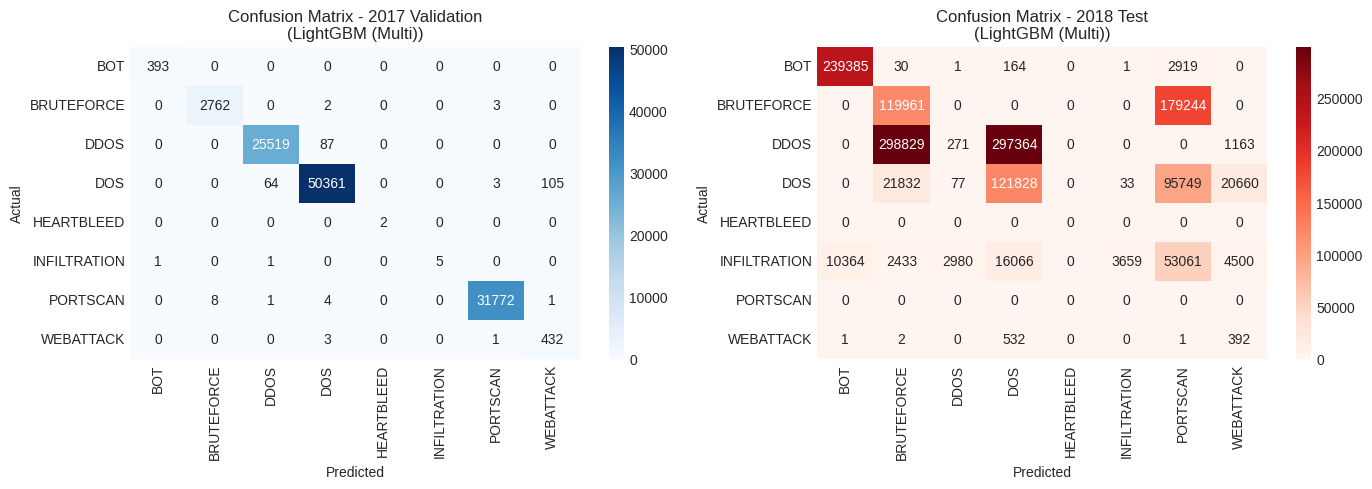


Classification Report (2018 Test):

              precision    recall  f1-score   support

         BOT       0.96      0.99      0.97    242500
  BRUTEFORCE       0.27      0.40      0.32    299205
        DDOS       0.08      0.00      0.00    597627
         DOS       0.28      0.47      0.35    260179
  HEARTBLEED       0.00      0.00      0.00         0
INFILTRATION       0.99      0.04      0.08     93063
    PORTSCAN       0.00      0.00      0.00         0
   WEBATTACK       0.01      0.42      0.03       928

    accuracy                           0.33   1493502
   macro avg       0.32      0.29      0.22   1493502
weighted avg       0.35      0.33      0.29   1493502



In [30]:
label_map = {
    0: "BENIGN",
    1: "BOT",
    2: "BRUTEFORCE",
    3: "DDOS",
    4: "DOS",
    5: "HEARTBLEED",
    6: "INFILTRATION",
    7: "PORTSCAN",
    8: "WEBATTACK"
}
print("TEST ON 2018 DATASET (UNSEEN) - MULTICLASS\n")
X_attack_2018_clean, _ = prepare_data(attack_2018, feature_cols)
y_attack_2018 = attack_2018["Attack_type"].values
X_attack_2018_clean = X_attack_2018_clean[common_features].sort_index(axis=1)
X_attack_2018_scaled = scaler.transform(X_attack_2018_clean)
X_attack_2018_scaled_df = pd.DataFrame(
    X_attack_2018_scaled,
    columns=X_attack_2018_clean.columns
)
X_attack_2018_highvar = X_attack_2018_scaled_df[high_var_features].values
X_attack_2018_anova = anova_selector.transform(X_attack_2018_highvar)
X_2018_pca = pca.transform(X_attack_2018_anova)
test_results = {}
for model_name, model in multi_models.items():
    print(f"Testing model: {model_name}")
    if "XGBoost" in model_name:
        y_pred = le_attack.inverse_transform(model.predict(X_2018_pca))
    else:
        y_pred = model.predict(X_2018_pca)
    acc = accuracy_score(y_attack_2018, y_pred)
    prec = precision_score(
        y_attack_2018,
        y_pred,
        average="macro",
        zero_division=0
    )
    rec = recall_score(
        y_attack_2018,
        y_pred,
        average="macro",
        zero_division=0
    )
    f1 = f1_score(
        y_attack_2018,
        y_pred,
        average="macro",
        zero_division=0
    )
    try:
        y_prob = model.predict_proba(X_2018_pca)
        y_true_encoded = le_attack.transform(y_attack_2018)
        valid_classes = np.unique(y_true_encoded)

        roc_auc = roc_auc_score(
            y_true_encoded,
            y_prob[:, valid_classes],
            multi_class="ovr",
            average="macro"
        )
    except:
        roc_auc = np.nan
    test_results[model_name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    }
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}\n")
best_model_name = max(test_results, key=lambda x: test_results[x]["F1-Score"])
best_model = multi_models[best_model_name]
print(f"\nBest model on 2018 dataset: {best_model_name}")
print(f"Metrics: {test_results[best_model_name]}")
if "XGBoost" in best_model_name:
    y_val_pred_best = le_attack.inverse_transform(best_model.predict(X_val_att))
    y_2018_pred = le_attack.inverse_transform(best_model.predict(X_2018_pca))
else:
    y_val_pred_best = best_model.predict(X_val_att)
    y_2018_pred = best_model.predict(X_2018_pca)
labels_present = np.unique(np.concatenate([y_val_att, y_2018_pred]))
plot_labels = [label_map[int(x)] for x in labels_present]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_val = confusion_matrix(
    y_val_att,
    y_val_pred_best,
    labels=labels_present
)
sns.heatmap(
    cm_val,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=plot_labels,
    yticklabels=plot_labels,
    ax=axes[0]
)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title(f"Confusion Matrix - 2017 Validation\n({best_model_name})")
cm_test = confusion_matrix(
    y_attack_2018,
    y_2018_pred,
    labels=labels_present
)
sns.heatmap(
    cm_test,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=plot_labels,
    yticklabels=plot_labels,
    ax=axes[1]
)
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title(f"Confusion Matrix - 2018 Test\n({best_model_name})")
plt.tight_layout()
plt.savefig("multiclass_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nClassification Report (2018 Test):\n")
print(
    classification_report(
        y_attack_2018,
        y_2018_pred,
        labels=labels_present,
        target_names=plot_labels
    )
)

In [34]:
save_root = "/kaggle/working/ids_model_bundle"
binary_dir = os.path.join(save_root, "binary_models")
multi_dir = os.path.join(save_root, "multiclass_models")
os.makedirs(save_root, exist_ok=True)
os.makedirs(binary_dir, exist_ok=True)
os.makedirs(multi_dir, exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
print("Saving preprocessing objects...")
def safe_dump(obj_name, filename):
    if obj_name in globals():
        joblib.dump(globals()[obj_name], os.path.join(save_root, filename))
        print(f"Saved {filename}")
    else:
        print(f"Skipped {filename} (not found)")
safe_dump("pca_binary", "pca_binary.joblib")
safe_dump("pca_multiclass", "pca_multiclass.joblib")
safe_dump("pca", "pca.joblib")  # fallback if only one PCA exists
safe_dump("scaler", "scaler.joblib")
safe_dump("anova_selector", "anova_selector.joblib")
safe_dump("label_encoder_binary", "label_encoder_binary.joblib")
safe_dump("label_encoder_multi", "label_encoder_multi.joblib")
safe_dump("common_features", "common_features.joblib")
safe_dump("high_var_features", "high_var_features.joblib")
def export_models(model_dict, save_dir, prefix):
    if "X_train_att" not in globals():
        print("Warning: X_train_att not found. Skipping ONNX export.")
        return
    n_features = X_train_att.shape[1]
    initial_type = [('input', FloatTensorType([None, n_features]))]
    for name, model in model_dict.items():
        safe = name.replace(" ","_").lower()
        print(f"Saving {prefix} model:", name)
        joblib_path = os.path.join(save_dir, f"{safe}.joblib")
        joblib.dump(model, joblib_path)
        try:
            onnx_model = convert_sklearn(model, initial_types=initial_type)
            onnx_path = os.path.join(save_dir, f"{safe}.onnx")
            with open(onnx_path, "wb") as f:
                f.write(onnx_model.SerializeToString())
            print("ONNX saved:", onnx_path)
        except Exception as e:
            print(f"ONNX conversion failed for {name}: {e}")
if "models" in globals():
    print("\nExporting Binary Models")
    export_models(models, binary_dir, "binary")
if "multi_models" in globals():
    print("\nExporting Multiclass Models")
    export_models(multi_models, multi_dir, "multi")
print("Saving metadata...")
metadata = {
    "created": timestamp,
    "dataset": {
        "train_dataset": "CICIDS2017",
        "test_dataset": "CICIDS2018"
    },
    "models": {
        "binary_models": list(models.keys()) if "models" in globals() else [],
        "multiclass_models": list(multi_models.keys()) if "multi_models" in globals() else []
    }
}
with open(os.path.join(save_root,"metadata.json"),"w") as f:
    json.dump(metadata,f,indent=4)
gpu_config = {
    "inference_engine": "onnxruntime",
    "providers": [
        "CUDAExecutionProvider",
        "CPUExecutionProvider"
    ],
    "recommended_batch_size": 4096,
    "precision": "float32"
}
with open(os.path.join(save_root,"gpu_config.json"),"w") as f:
    json.dump(gpu_config,f,indent=4)
print("Creating ZIP bundle...")
zip_path = "/kaggle/working/ids_model_bundle.zip"
with zipfile.ZipFile(zip_path,'w',zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(save_root):
        for file in files:
            full_path = os.path.join(root, file)
            arcname = os.path.relpath(full_path, save_root)
            zipf.write(full_path, arcname)
print("\nBundle created:")
print(zip_path)
print("\nIDS MODEL BUNDLE READY")
print("Location:", save_root)

Saving preprocessing objects...
Skipped pca_binary.joblib (not found)
Skipped pca_multiclass.joblib (not found)
Saved pca.joblib
Saved scaler.joblib
Saved anova_selector.joblib
Skipped label_encoder_binary.joblib (not found)
Skipped label_encoder_multi.joblib (not found)
Saved common_features.joblib
Saved high_var_features.joblib

Exporting Binary Models
Saving binary model: Logistic Regression
ONNX saved: /kaggle/working/ids_model_bundle/binary_models/logistic_regression.onnx
Saving binary model: Decision Tree
ONNX saved: /kaggle/working/ids_model_bundle/binary_models/decision_tree.onnx
Saving binary model: XGBoost (CPU)
ONNX conversion failed for XGBoost (CPU): Unable to find a shape calculator for type '<class 'xgboost.sklearn.XGBClassifier'>'.
It usually means the pipeline being converted contains a
transformer or a predictor with no corresponding converter
implemented in sklearn-onnx. If the converted is implemented
in another library, you need to register
the converted so that it